#VGG16 results

In [4]:
import os
import zipfile


zip_path = r'D:\Python workspace\dataset.zip' 
extract_path = 'data/'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted to:", extract_path)


print("Folders inside extracted dataset:")
print(os.listdir(extract_path))


Dataset extracted to: data/
Folders inside extracted dataset:
['brain_tumor_dataset', 'no', 'yes']


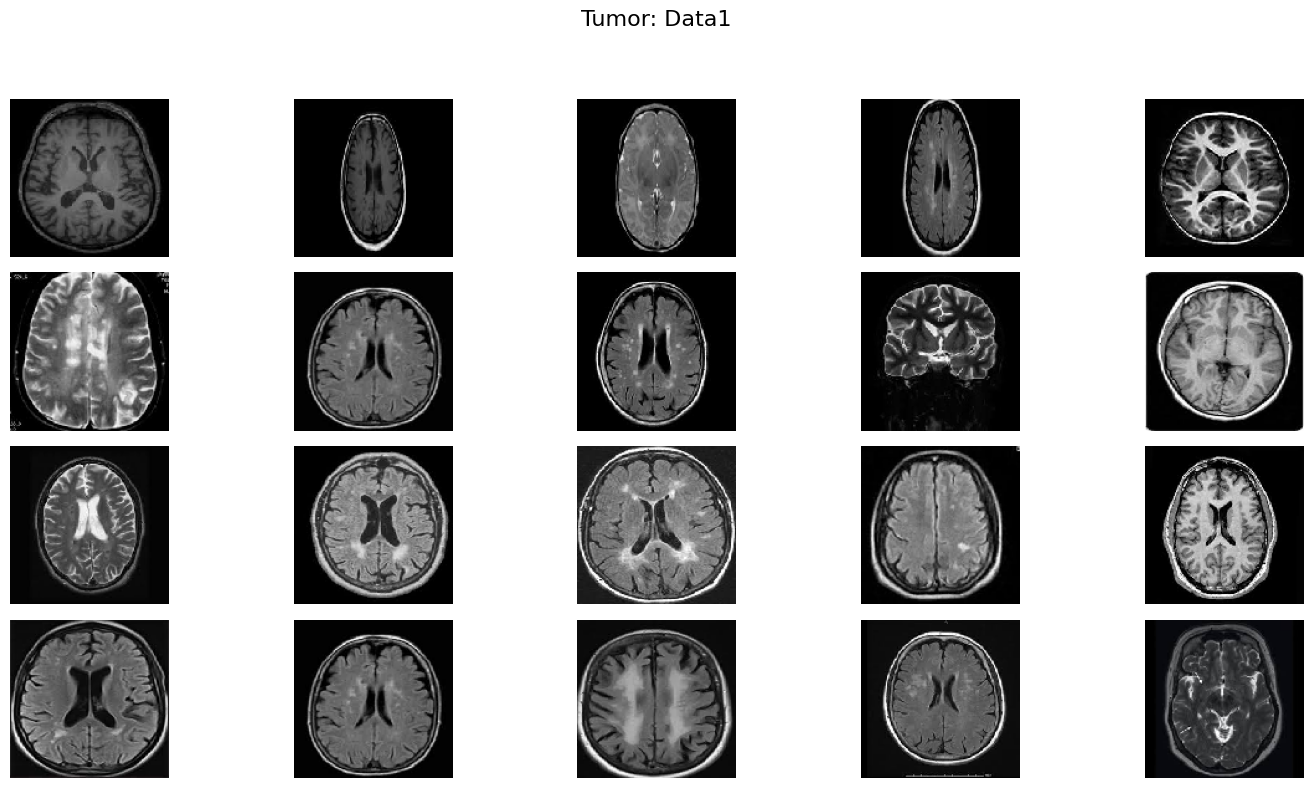

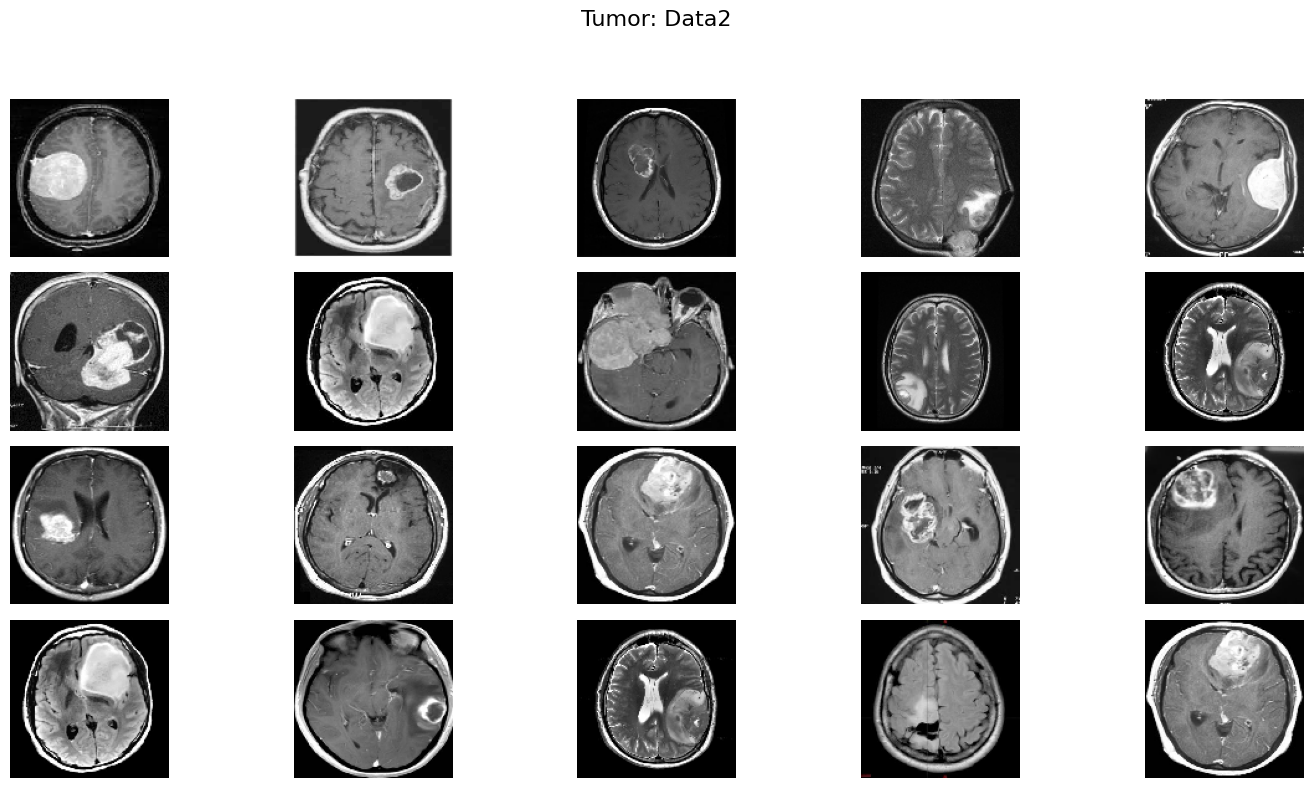

In [5]:
import os
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

def plot_mri_grid(class_dir, label, n_images=20):
    img_files = [os.path.join(class_dir, fname) for fname in os.listdir(class_dir) if fname.endswith('.jpg') or fname.endswith('.png')]
    plt.figure(figsize=(15,8))
    plt.suptitle(f"Tumor: {label}", fontsize=16)
    for i, img_path in enumerate(img_files[:n_images]):
        plt.subplot(4, 5, i+1)
        img = image.load_img(img_path, target_size=(128,128))
        plt.imshow(img, cmap='gray')
        plt.axis('off')
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()

# Tumor NO grid
plot_mri_grid('data/no', 'Data1', n_images=20)   # Adjust path as per your folder structure

# Tumor YES grid
plot_mri_grid('data/yes', 'Data2', n_images=20)


In [6]:
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator

dataset_path = 'data/brain_tumor_dataset'

# Image size and batch size
img_size = 224
batch_size = 32

# ImageDataGenerator with augmentation for training data
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,  # 20% data validation
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Validation data generator without augmentation
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary',
    subset='training',
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    dataset_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation',
    shuffle=False
)

print("Training samples:", train_generator.samples)
print("Validation samples:", val_generator.samples)


Found 203 images belonging to 2 classes.
Found 50 images belonging to 2 classes.
Training samples: 203
Validation samples: 50


In [7]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Load VGG16 base model without top layers
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the base model layers
base_model.trainable = False

# Add custom classification layers on top
x = Flatten()(base_model.output)
x = Dense(128, activation='relu')(x)
outputs = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=outputs)

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Train the model
history_vgg16  = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)


Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 37s 5s/step - accuracy: 0.4828 - loss: 2.0587 - val_accuracy: 0.6200 - val_loss: 0.9489
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 56s 7s/step - accuracy: 0.6108 - loss: 1.3046 - val_accuracy: 0.7600 - val_loss: 0.4985
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 94s 9s/step - accuracy: 0.5764 - loss: 0.7000 - val_accuracy: 0.7800 - val_loss: 0.5052
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 58s 9s/step - accuracy: 0.7044 - loss: 0.5379 - val_accuracy: 0.7800 - val_loss: 0.4908
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 52s 7s/step - accuracy: 0.7685 - loss: 0.5093 - val_accuracy: 0.8000 - val_loss: 0.5218
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 42s 6s/step - accuracy: 0.8128 - loss: 0.4784 - val_accuracy: 0.7600 - val_loss: 0.4552
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 54s 8s/step - accuracy: 0.7783 - loss: 0.4897 - val_accuracy: 0.8000 - val_loss: 0.5349
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 42s 6s/step - accuracy: 0.7931 - loss: 0.4763 - val_accuracy: 0.8000 - val_loss: 0.4504
Epoch 9/

In [8]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# VGG16 base model load with pretrained weights 
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))


base_model.trainable = False

# custom classification layers add
x = Flatten()(base_model.output)
x = Dense(128, activation='relu')(x)
outputs = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=outputs)

# Model compile karein with loss and optimizer
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

history_vgg16  = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)


Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 42s 6s/step - accuracy: 0.5517 - loss: 2.0634 - val_accuracy: 0.6200 - val_loss: 1.2489
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 44s 6s/step - accuracy: 0.6552 - loss: 1.1404 - val_accuracy: 0.5200 - val_loss: 1.0119
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 60s 9s/step - accuracy: 0.6305 - loss: 0.8805 - val_accuracy: 0.7600 - val_loss: 0.7392
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 64s 9s/step - accuracy: 0.7241 - loss: 0.5510 - val_accuracy: 0.7600 - val_loss: 0.4423
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 43s 6s/step - accuracy: 0.7783 - loss: 0.4965 - val_accuracy: 0.7800 - val_loss: 0.4127
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 35s 5s/step - accuracy: 0.8079 - loss: 0.4090 - val_accuracy: 0.7600 - val_loss: 0.4003
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 35s 5s/step - accuracy: 0.8522 - loss: 0.3995 - val_accuracy: 0.8200 - val_loss: 0.3854
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 34s 5s/step - accuracy: 0.8719 - loss: 0.3569 - val_accuracy: 0.8400 - val_loss: 0.3838
Epoch 9/

In [80]:
model.save("vgg16_model.h5")

2/2 ━━━━━━━━━━━━━━━━━━━━ 9s 4s/step
              precision    recall  f1-score   support

    No Tumor       0.85      0.58      0.69        19
       Tumor       0.78      0.94      0.85        31

    accuracy                           0.80        50
   macro avg       0.81      0.76      0.77        50
weighted avg       0.81      0.80      0.79        50



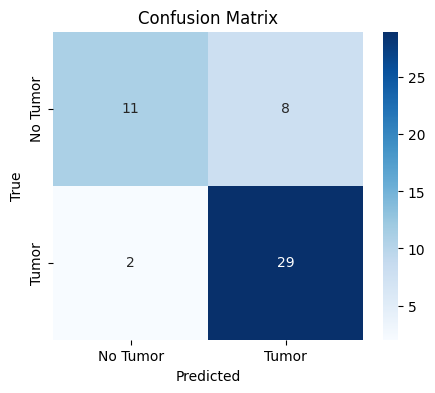

In [9]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Predict values for validation set
val_generator.reset()
preds = model.predict(val_generator)
pred_labels = (preds > 0.5).astype(int)

true_labels = val_generator.classes

# Classification report
print(classification_report(true_labels, pred_labels, target_names=['No Tumor', 'Tumor']))

# Confusion Matrix
cm = confusion_matrix(true_labels, pred_labels)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Tumor', 'Tumor'], yticklabels=['No Tumor', 'Tumor'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


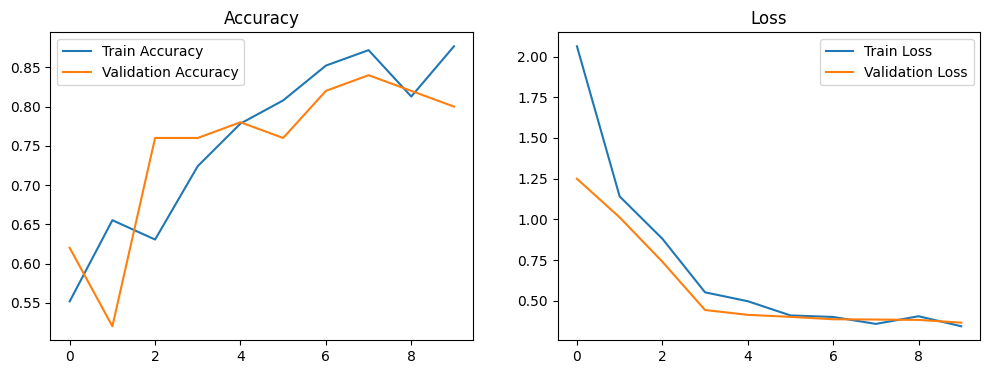

In [10]:
# Plot training & validation accuracy and loss
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history_vgg16 .history ['accuracy'], label='Train Accuracy')
plt.plot(history_vgg16 .history ['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(history_vgg16 .history ['loss'], label='Train Loss')
plt.plot(history_vgg16 .history ['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss')

plt.show()


In [11]:
from tensorflow.keras.preprocessing import image
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.applications.vgg16 import preprocess_input

def get_img_array(img_path, size):
    img = image.load_img(img_path, target_size=size)
    array = image.img_to_array(img)
    array = np.expand_dims(array, axis=0)
    return preprocess_input(array)

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = Model(
        [model.inputs], 
        [model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def overlay_heatmap(img_path, heatmap, alpha=0.4):
    img = image.load_img(img_path)
    img = image.img_to_array(img)
    # Resize heatmap to image size
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    jet = plt.cm.get_cmap("jet")
    heatmap_colored = jet(heatmap)[:, :, :3]
    heatmap_colored = np.uint8(255 * heatmap_colored)
    # Superimpose the heatmap on original image
    superimposed_img = cv2.addWeighted(img.astype(np.uint8), 1 - alpha, heatmap_colored, alpha, 0)
    plt.figure(figsize=(8, 8))
    plt.imshow(superimposed_img.astype(np.uint8))
    plt.axis('off')
    plt.show()


d:\Python workspace\venv\Lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_26']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)
C:\Users\User\AppData\Local\Temp\ipykernel_6800\854732830.py:40: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = plt.cm.get_cmap("jet")


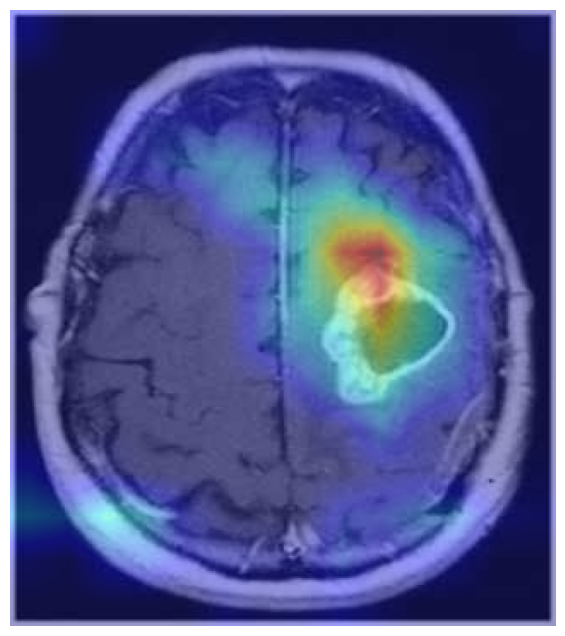

In [12]:
img_path = 'data/yes/Y10.jpg'
img_size = (224, 224)
last_conv_layer_name = 'block5_conv3'
img_array = get_img_array(img_path, img_size)
heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)
overlay_heatmap(img_path, heatmap)


In [13]:
import os

print(os.listdir())  # current directory ke sab files dikhayega


['CS26S32083061_AdmitCard.pdf', 'DA26S82083059_AdmitCard.pdf', 'data', 'final_year_project[less_accuracy].ipynb', 'Online Recruitment Drive for Atidan Technologies Pvt. Ltd. - Organised by VibrantMinds (2).pdf']


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 904ms/step


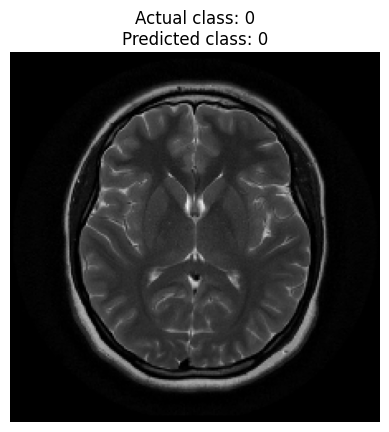

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 472ms/step


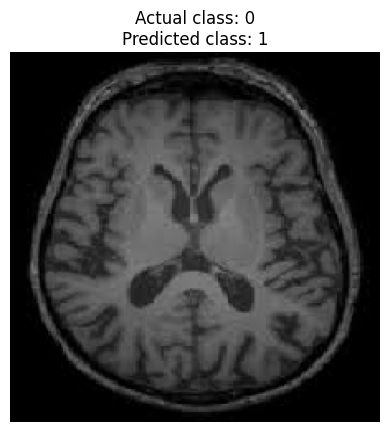

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 480ms/step


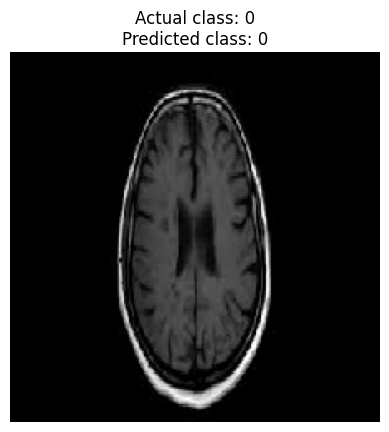

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 465ms/step


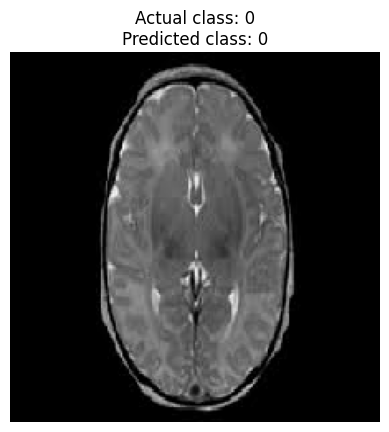

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 502ms/step


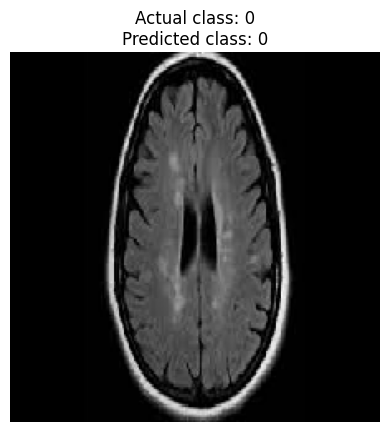

In [14]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
import numpy as np

# Example - verify on n images from validation set
n = 5  
val_generator.reset()
img_paths = [val_generator.filepaths[i] for i in range(n)]
true_labels = [val_generator.classes[i] for i in range(n)]
class_names = ['No Tumor', 'Tumor']

for i in range(n):
    img = image.load_img(img_paths[i], target_size=(224, 224))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0) / 255.0

    pred = model.predict(x)
    pred_class = int(pred[0][0] > 0.5)

    plt.imshow(img, cmap='gray')
    plt.axis('off')
    plt.title(f'Actual class: {true_labels[i]}\nPredicted class: {pred_class}')
    plt.show()


#restnet50

In [15]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, Flatten, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Load the ResNet50 base model (use imagenet weights, no top layer)
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze base model
base_model.trainable = False

# Custom classification layers
x = GlobalAveragePooling2D()(base_model.output)  # GlobalAveragePooling (preferred for ResNet)
x = Dense(128, activation='relu')(x)
outputs = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=outputs)

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Training (use same train_generator and val_generator as before)
history_resnet50 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)


Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 45s 4s/step - accuracy: 0.5813 - loss: 0.7270 - val_accuracy: 0.6200 - val_loss: 0.6518
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 23s 3s/step - accuracy: 0.6355 - loss: 0.6703 - val_accuracy: 0.4400 - val_loss: 0.7047
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 19s 3s/step - accuracy: 0.4828 - loss: 0.7170 - val_accuracy: 0.6200 - val_loss: 0.6798
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 22s 3s/step - accuracy: 0.6355 - loss: 0.6443 - val_accuracy: 0.7000 - val_loss: 0.6349
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 22s 3s/step - accuracy: 0.6355 - loss: 0.6286 - val_accuracy: 0.6800 - val_loss: 0.6060
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 19s 3s/step - accuracy: 0.6749 - loss: 0.6105 - val_accuracy: 0.6200 - val_loss: 0.5794
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 18s 3s/step - accuracy: 0.6650 - loss: 0.6152 - val_accuracy: 0.6400 - val_loss: 0.5701
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 21s 3s/step - accuracy: 0.6700 - loss: 0.6235 - val_accuracy: 0.7000 - val_loss: 0.6016
Epoch 9/

ResNet50 Model Training Block

In [16]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Load ResNet50 base
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

# Custom layers
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(128, activation='relu')(x)
outputs = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=outputs)
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Train the model
history_resnet50 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)


Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 52s 5s/step - accuracy: 0.5764 - loss: 0.7382 - val_accuracy: 0.6200 - val_loss: 0.8677
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 29s 4s/step - accuracy: 0.6158 - loss: 0.7530 - val_accuracy: 0.3800 - val_loss: 0.7351
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 21s 3s/step - accuracy: 0.4975 - loss: 0.7072 - val_accuracy: 0.6200 - val_loss: 0.6795
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 17s 3s/step - accuracy: 0.6207 - loss: 0.6784 - val_accuracy: 0.6400 - val_loss: 0.6319
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.6601 - loss: 0.6490 - val_accuracy: 0.6400 - val_loss: 0.6212
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 17s 3s/step - accuracy: 0.6355 - loss: 0.6203 - val_accuracy: 0.6800 - val_loss: 0.6035
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.6897 - loss: 0.6100 - val_accuracy: 0.6400 - val_loss: 0.6019
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 23s 3s/step - accuracy: 0.6946 - loss: 0.6011 - val_accuracy: 0.6400 - val_loss: 0.6204
Epoch 9/

In [81]:
model.save("resnet50_model.h5")

Model Evaluation Block

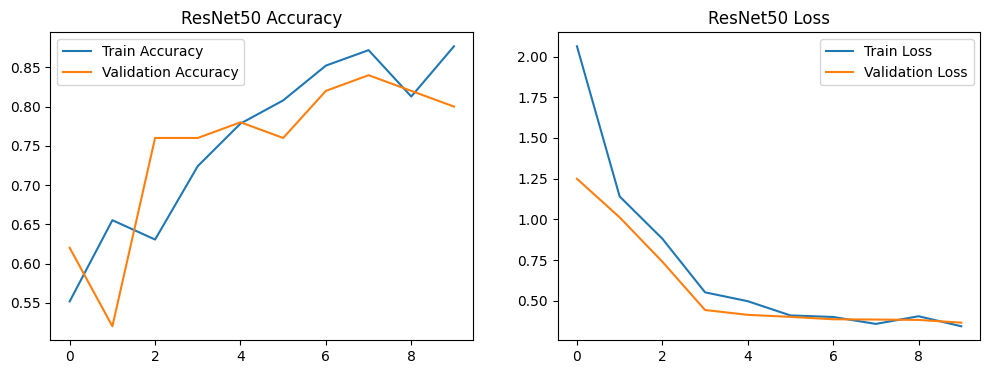

In [17]:
import matplotlib.pyplot as plt

# Accuracy and loss plots
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history_vgg16 .history['accuracy'], label='Train Accuracy')
plt.plot(history_vgg16 .history['val_accuracy'], label='Validation Accuracy')
plt.title('ResNet50 Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_vgg16 .history['loss'], label='Train Loss')
plt.plot(history_vgg16 .history['val_loss'], label='Validation Loss')
plt.title('ResNet50 Loss')
plt.legend()
plt.show()


1/2 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/stepWARNING:tensorflow:5 out of the last 9 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x000001B8022DC040> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
2/2 ━━━━━━━━━━━━━━━━━━━━ 13s 6s/step
              precision    recall  f1-score   support

    No Tumor       0.80      0.21      0.33        19
       Tumor       0.67      0.97      0.79        31

    accuracy                          

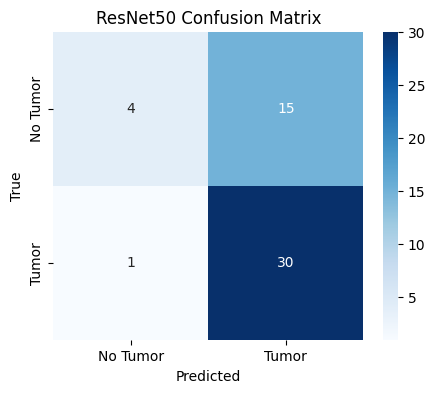

In [18]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import seaborn as sns

val_generator.reset()
preds = model.predict(val_generator)
pred_labels = (preds > 0.5).astype(int)
true_labels = val_generator.classes

print(classification_report(true_labels, pred_labels, target_names=['No Tumor', 'Tumor']))

cm = confusion_matrix(true_labels, pred_labels)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Tumor', 'Tumor'], yticklabels=['No Tumor', 'Tumor'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('ResNet50 Confusion Matrix')
plt.show()


d:\Python workspace\venv\Lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_236']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)
C:\Users\User\AppData\Local\Temp\ipykernel_6800\854732830.py:40: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = plt.cm.get_cmap("jet")


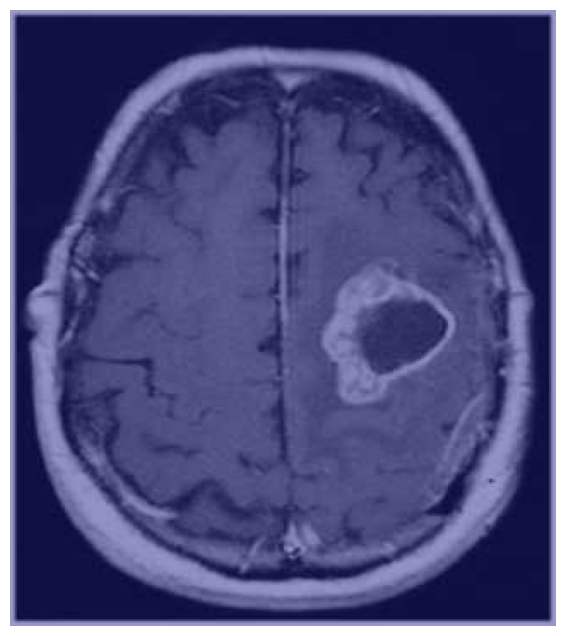

In [19]:
img_path = 'data/yes/Y10.jpg'
img_size = (224, 224)
last_conv_layer_name = 'conv5_block3_out'  # ResNet50 last conv layer

img_array = get_img_array(img_path, img_size)
heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)
overlay_heatmap(img_path, heatmap)


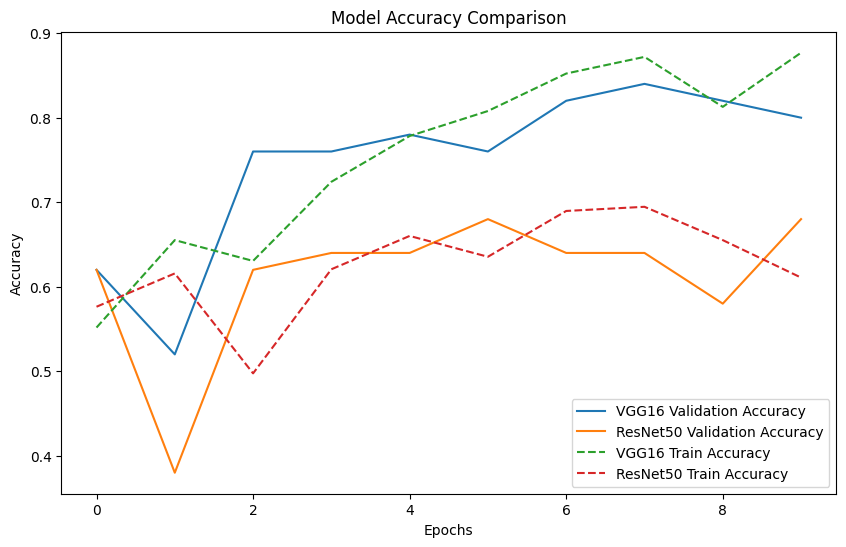

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(history_vgg16.history['val_accuracy'], label='VGG16 Validation Accuracy')
plt.plot(history_resnet50.history['val_accuracy'], label='ResNet50 Validation Accuracy')
plt.plot(history_vgg16.history['accuracy'], linestyle='--', label='VGG16 Train Accuracy')
plt.plot(history_resnet50.history['accuracy'], linestyle='--', label='ResNet50 Train Accuracy')

plt.title('Model Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.show()


In [21]:
import os
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

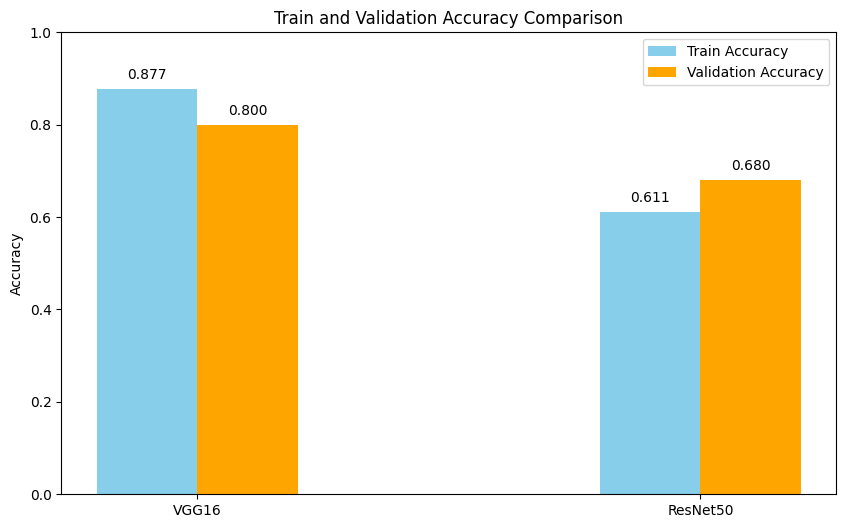

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# Final train and validation accuracies (replace with your actual values)
train_acc_vgg16 = history_vgg16.history['accuracy'][-1]
val_acc_vgg16 = history_vgg16.history['val_accuracy'][-1]
train_acc_resnet50 = history_resnet50.history['accuracy'][-1]
val_acc_resnet50 = history_resnet50.history['val_accuracy'][-1]

models = ['VGG16', 'ResNet50']
train_accuracies = [train_acc_vgg16, train_acc_resnet50]
val_accuracies = [val_acc_vgg16, val_acc_resnet50]

x = np.arange(len(models))  # label locations
width = 0.2  # width of bars

fig, ax = plt.subplots(figsize=(10,6))
rects1 = ax.bar(x - width/2, train_accuracies, width, label='Train Accuracy', color='skyblue')
rects2 = ax.bar(x + width/2, val_accuracies, width, label='Validation Accuracy', color='orange')

ax.set_ylabel('Accuracy')
ax.set_title('Train and Validation Accuracy Comparison')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0,1)
ax.legend()

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 5),  # vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

plt.show()


In [68]:
import os
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

In [69]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    zoom_range=0.3,
    shear_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8,1.2],
    validation_split=0.2
)

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    zoom_range=0.3,
    shear_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8,1.2],
    validation_split=0.2
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = train_datagen.flow_from_directory(
    r'D:\Python workspace\data',
    target_size=(128,128),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

val_data = val_datagen.flow_from_directory(
    r'D:\Python workspace\data',
    target_size=(128,128),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 203 images belonging to 2 classes.


Found 50 images belonging to 2 classes.


In [70]:
K.clear_session()

In [71]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(128,128,3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)

output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

In [72]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [73]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(patience=3, restore_best_weights=True)
lr_reduce = ReduceLROnPlateau(patience=2, factor=0.3)

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    callbacks=[early_stop, lr_reduce]
)

Epoch 1/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 589ms/step - accuracy: 0.5074 - loss: 0.9551 - val_accuracy: 0.6200 - val_loss: 0.6531 - learning_rate: 1.0000e-04
Epoch 2/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 360ms/step - accuracy: 0.5764 - loss: 0.8742 - val_accuracy: 0.6800 - val_loss: 0.5950 - learning_rate: 1.0000e-04
Epoch 3/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 350ms/step - accuracy: 0.6158 - loss: 0.7947 - val_accuracy: 0.7000 - val_loss: 0.5472 - learning_rate: 1.0000e-04
Epoch 4/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 368ms/step - accuracy: 0.5862 - loss: 0.7926 - val_accuracy: 0.7600 - val_loss: 0.5138 - learning_rate: 1.0000e-04
Epoch 5/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 479ms/step - accuracy: 0.6404 - loss: 0.6580 - val_accuracy: 0.7800 - val_loss: 0.4929 - learning_rate: 1.0000e-04
Epoch 6/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 490ms/step - accuracy: 0.7094 - loss: 0.5999 - val_accuracy: 0.8000 - val_loss: 0.4696 - learning_rate: 1.0000e-04
Epoch 7/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 440ms/step - accuracy: 0.6650 - loss:

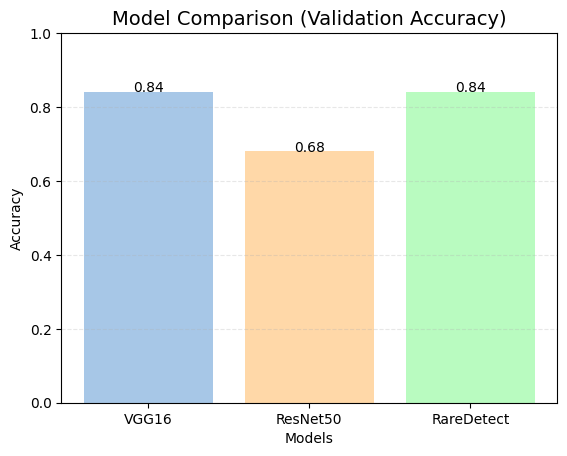

In [ ]:
import matplotlib.pyplot as plt

# accuracies
vgg_acc = max(history_vgg16.history['val_accuracy'])
resnet_acc = max(history_resnet50.history['val_accuracy'])
rare_detect_acc = max(history.history['val_accuracy'])

models = ['VGG16', 'ResNet50', 'RareDetect']
accuracies = [vgg_acc, resnet_acc, rare_detect_acc]

# 🌸 soft aesthetic colors
colors = ['#A7C7E7', '#FFD8A8', '#B9FBC0']  

plt.figure()
bars = plt.bar(models, accuracies, color=colors)

plt.title("Model Comparison (Validation Accuracy)", fontsize=14)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.ylim(0,1)

# values on top
for i, v in enumerate(accuracies):
    plt.text(i, v, f"{v:.2f}", ha='center', fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.3)  # light grid

plt.show()

In [79]:
model.save("raredetect_model.h5")